## Figure S8: Note Similarity of Resemblance Pairs

Distribution of the note Jaccard index for every `this_perfume_reminds_ids` pair vs a random-pair null. The two red lines mark the data-driven cutoffs reused downstream: the J leaving the top 10% (`J_TOP10`) and top 5% (`J_TOP5`) most note-similar pairs.

cutoff: Total_votes >= 286  ->  16,210/92,589 perfumes eligible
resemblance pairs: n=169,991 | mean=0.172 median=0.150
data-driven cutoffs:  top-10% -> J >= 0.316   |   top-5% -> J >= 0.389
random pairs:   mean=0.088 median=0.074 | >=0.3: 1.2%
Mann-Whitney U (two-sided): P=0.00e+00 | CLES P(resemblance>random)=0.722 | Cohen's d=0.777


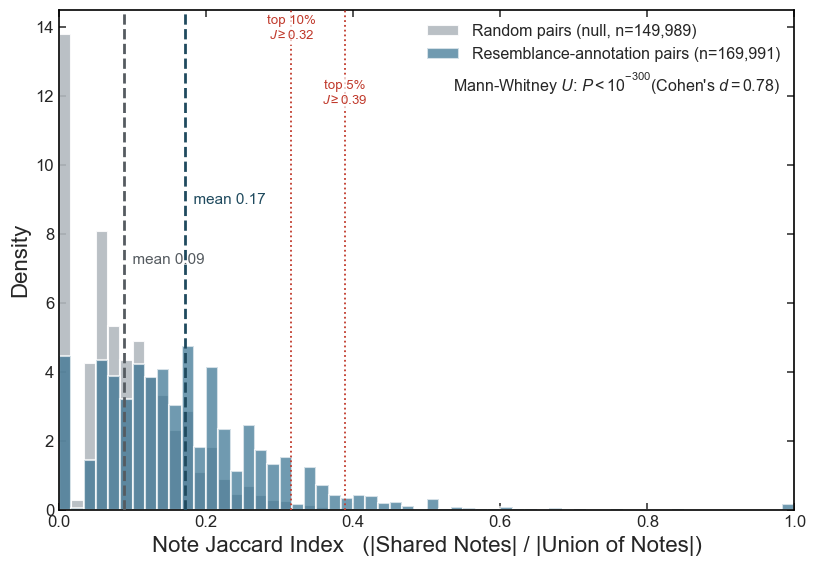

In [1]:
# ===========================================================================
import matplotlib as _mpl
_mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif'],
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial', 'mathtext.it': 'Arial:italic', 'mathtext.bf': 'Arial:bold',
    'svg.fonttype': 'path',          
    'pdf.fonttype': 42, 'ps.fonttype': 42, 
})
# ===========================================================================

# Note-Jaccard distribution for resemblance pairs vs a random-pair null (Figure S8)
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from scipy import stats, sparse
from statsmodels.stats.multitest import multipletests
sys.path.append(os.path.abspath(".."))
from utils.utils import parse_notes
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'DejaVu Sans'],
                     'axes.linewidth': 1.1, 'xtick.direction': 'in', 'ytick.direction': 'in'})
OUT_DIR = "../output"; os.makedirs(OUT_DIR, exist_ok=True)

cols = ['perfume name', 'year', 'this_perfume_reminds_ids', 'id', 'price_rating', 'notes', 'accords']
df = pd.read_csv("../dataset/Fragrantica.csv", usecols=cols, low_memory=False)
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['note_list'] = df['notes'].apply(parse_notes)
def _plist(s):
    try:
        v = json.loads(s) if isinstance(s, str) else []
        return v if isinstance(v, list) else []
    except Exception:
        return []
df['reminds'] = df['this_perfume_reminds_ids'].apply(_plist)

def _value(s):
    try:
        d = json.loads(s) if isinstance(s, str) else {}
        t = sum(d.values())
        return (sum(int(k) * v for k, v in d.items()) / t, t) if t > 0 else (np.nan, 0)
    except Exception:
        return (np.nan, 0)
vv = df['price_rating'].apply(_value); df['value'] = [x[0] for x in vv]; df['nvotes'] = [x[1] for x in vv]

def _accset(s):
    try:
        d = json.loads(s) if isinstance(s, str) else {}
        return {('floral' if k == 'white floral' else k) for k, v in d.items() if v > 0}
    except Exception:
        return set()
df['accord_set'] = df['accords'].apply(_accset)

id2idx = {int(pid): i for i, pid in enumerate(df['id'])}

yr = df['year'].values
edges = []
for p, rem in enumerate(df['reminds']):
    yp = yr[p]
    if np.isnan(yp):
        continue
    for rname in rem:
        r = id2idx.get(int(rname))
        if r is not None and not np.isnan(yr[r]) and yp > yr[r]:
            edges.append((r, p))
edges = np.array(edges)
val_arr = df['value'].values

from utils.utils import parse_notes_weighted
nsets = [set(parse_notes_weighted(s)) for s in df['notes']]

WEIGHTS_MIN = 286
if 'Total_votes' not in df.columns:
    df['Total_votes'] = pd.to_numeric(
        pd.read_csv("../dataset/Fragrantica.csv", usecols=['Total_votes'])['Total_votes'],
        errors='coerce').values
keep = (df['Total_votes'].values >= WEIGHTS_MIN) if WEIGHTS_MIN is not None else np.ones(len(df), bool)
_cut = 'no cutoff (full set)' if WEIGHTS_MIN is None else f'Total_votes >= {WEIGHTS_MIN}'
print(f"cutoff: {_cut}  ->  {int(keep.sum()):,}/{len(df):,} perfumes eligible")

def _jac(a, b):
    u = len(a | b)
    return len(a & b) / u if u else np.nan

rj = []
for p, rem in enumerate(df['reminds']):
    a = nsets[p]
    if not a or not keep[p]:
        continue
    for rn in rem:
        r = id2idx.get(int(rn))
        if r is None or not keep[r]:
            continue
        b = nsets[r]
        if b:
            rj.append(_jac(a, b))
rj = np.array(rj)
J_TOP10 = float(np.quantile(rj, 0.90))
J_TOP5  = float(np.quantile(rj, 0.95))

rng = np.random.default_rng(0)
withnotes = np.array([i for i in range(len(df)) if nsets[i] and keep[i]])
m = min(len(rj), 150000)
ia = rng.choice(withnotes, m); ib = rng.choice(withnotes, m)
nullj = np.array([_jac(nsets[i], nsets[j]) for i, j in zip(ia, ib) if i != j])

print(f"resemblance pairs: n={len(rj):,} | mean={rj.mean():.3f} median={np.median(rj):.3f}")
print(f"data-driven cutoffs:  top-10% -> J >= {J_TOP10:.3f}   |   top-5% -> J >= {J_TOP5:.3f}")
print(f"random pairs:   mean={nullj.mean():.3f} median={np.median(nullj):.3f} "
      f"| >=0.3: {100*(nullj>=0.3).mean():.1f}%")

from scipy.stats import mannwhitneyu
import seaborn as sns
sns.set_theme(style="white", context="talk")
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'DejaVu Sans']})

U, p_mwu = mannwhitneyu(rj, nullj, alternative='two-sided')
cles = U / (len(rj) * len(nullj))
pooled_sd = np.sqrt(((len(rj) - 1) * rj.var(ddof=1) + (len(nullj) - 1) * nullj.var(ddof=1))
                    / (len(rj) + len(nullj) - 2))
cohen_d = (rj.mean() - nullj.mean()) / pooled_sd
p_txt = r"$P < 10^{-300}$" if p_mwu < 1e-300 else f"$P = {p_mwu:.1e}$"
print(f"Mann-Whitney U (two-sided): P={p_mwu:.2e} | CLES P(resemblance>random)={cles:.3f} | Cohen's d={cohen_d:.3f}")

C_REAL, C_NULL = '#34708f', '#b3b9bf'
bins = np.linspace(0, 1, 61)
fig, ax = plt.subplots(figsize=(8.5, 6))
ax.hist(nullj, bins=bins, density=True, color=C_NULL, alpha=0.9, lw=0,
        label=f'Random pairs (null, n={len(nullj):,})', zorder=1)
ax.hist(rj, bins=bins, density=True, color=C_REAL, alpha=0.7, lw=0,
        label=f'Resemblance-annotation pairs (n={len(rj):,})', zorder=2)
ymax = ax.get_ylim()[1]

ax.axvline(nullj.mean(), color='#555b60', lw=2, ls='--', zorder=3)
ax.axvline(rj.mean(),    color='#1f4a5e', lw=2, ls='--', zorder=3)
ax.text(nullj.mean(), ymax * 0.50, f'  mean {nullj.mean():.2f}', color='#555b60', fontsize=11, va='center')
ax.text(rj.mean(),    ymax * 0.62, f'  mean {rj.mean():.2f}',    color='#1f4a5e', fontsize=11, va='center')

for jc, lbl, yfac in [(J_TOP10, 'top 10%', 0.99), (J_TOP5, 'top 5%', 0.86)]:
    ax.axvline(jc, color='#c0392b', lw=1.3, ls=':', zorder=3)
    ax.text(jc, ymax * yfac, f'{lbl}\n$J\\geq{jc:.2f}$', color='#c0392b', fontsize=9.5, ha='center', va='top',
            zorder=5, bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor='none'))

box = (f"Mann-Whitney $U$: {p_txt}(Cohen's $d={cohen_d:.2f})$")
ax.text(0.98, 0.88, box, transform=ax.transAxes, ha='right', va='top', fontsize=11.5,
        bbox=dict(boxstyle='round,pad=0.45', fc='white', ec='none', lw=1.0))

ax.set_xlabel('Note Jaccard Index   (|Shared Notes| / |Union of Notes|)', fontsize=16)
ax.set_ylabel('Density', fontsize=16)
ax.set_xlim(0, 1)
ax.tick_params(axis='both', which='both', direction='in', length=5, width=1.1,
               bottom=True, left=True, top=True, right=True, labelsize=12)
ax.legend(frameon=False, fontsize=11.5, loc='upper right')

for spine in ax.spines.values():
    spine.set_visible(True); spine.set_color('black'); spine.set_linewidth(1.2)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'Figure_S8.pdf'), format='pdf', dpi=300, bbox_inches='tight')
plt.show()


## Figure 3A: Evolutionary Copy Lineage Network

Copy lineage network for the top `K_TREES` Originals. Each copy sits under its primary parent (the original it most resembles, top-5% Jaccard); a strong second parent adds a dashed branch. Same-house descendants are Flankers (diamond), different-house are Clones (circle), lineage roots are Originals (star). x = release year, branch shade = Jaccard, node color = price value, size = number of descendants.

Original lineages: ['Chanel No 5', 'Aventus']
secondary (two-parent) merge links drawn: 43
tree nodes: 2 Original(s) | 79 clones (diff house) | 23 flankers (same house)


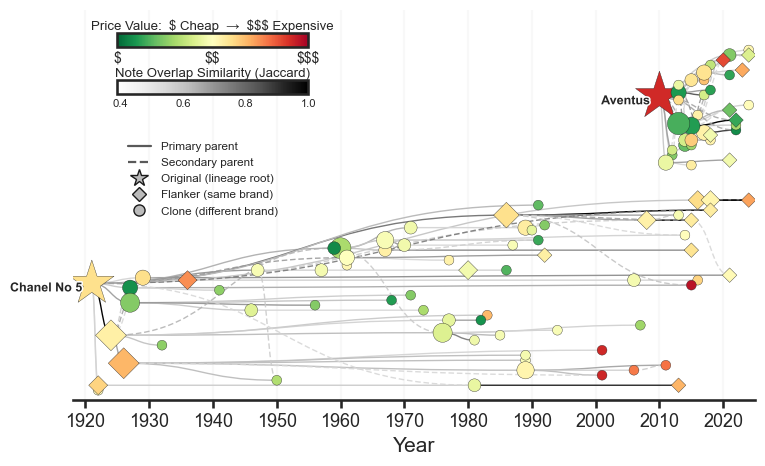

In [2]:
# Top-2 evolutionary copy lineage network with two-parent merges (Figure 3A)
import sys as _sys, json, re
import networkx as nx
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.path import Path
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from collections import defaultdict

J_MIN = J_TOP5
SEC_MIN = J_TOP5
GREAT_VALUE = 5.0
K_TREES = 2
yr = df['year'].values; val = df['value'].values

def _value_median(s):
    try:
        d = {int(k): v for k, v in (json.loads(s) if isinstance(s, str) else {}).items()}
    except Exception:
        return np.nan
    N = sum(d.values())
    if N <= 0:
        return np.nan
    half, cum = N / 2.0, 0
    for k in (1, 2, 3, 4, 5):
        f = d.get(k, 0)
        if cum + f >= half:
            return (k - 0.5) + (half - cum) / f if f > 0 else float(k)
        cum += f
    return 5.0
pval = df['price_rating'].apply(_value_median).values

def _clean(nm):
    nm = re.sub(r'\s+(Extrait de Parfum|Eau de Parfum|Eau de Toilette|Eau de Cologne|Parfum|Cologne|Elixir|EDP|EDT)\b.*$', '', str(nm)).strip()
    t = nm.split()
    for k in range(min(4, len(t) // 2), 0, -1):
        if t[:k] == t[-k:] and len(t) > k:
            nm = " ".join(t[:-k]); break
    return nm.strip()

def _term(i):
    return (not np.isnan(val[i])) and (val[i] >= GREAT_VALUE)

in_edges = defaultdict(list)
for r, p in edges:
    r, p = int(r), int(p)
    if _term(r) or not keep[r] or not keep[p]:
        continue
    a, b = nsets[r], nsets[p]
    if not a or not b:
        continue
    j = len(a & b) / len(a | b)
    if j >= J_MIN:
        in_edges[p].append((j, r))
allpar = {p: sorted(lst, reverse=True) for p, lst in in_edges.items()}
parent = {p: lp[0][1] for p, lp in allpar.items()}
pj = {p: lp[0][0] for p, lp in allpar.items()}
secondary = {p: lp[1] for p, lp in allpar.items() if len(lp) >= 2 and lp[1][0] >= SEC_MIN}

T = nx.DiGraph()
for p, par in parent.items():
    T.add_edge(par, p, w=pj[p])
trees = sorted(nx.weakly_connected_components(T), key=len, reverse=True)[:K_TREES]

_sys.setrecursionlimit(10000)
def _tidy(root, children):
    local, c = {}, [0]
    def rec(n):
        ch = sorted(children.get(n, []), key=lambda x: yr[x])
        if not ch:
            local[n] = c[0]; c[0] += 1
        else:
            for x in ch:
                rec(x)
            local[n] = float(np.mean([local[x] for x in ch]))
    rec(root)
    return local, c[0]

vnorm = Normalize(1, 5); vcmap = plt.cm.RdYlGn
jnorm = Normalize(J_MIN, 1.0); ecmap = plt.cm.Greys
pos, roots, subTs = {}, [], []
offset = 0.0; GAP = 6.0
for comp in trees:
    Tc = T.subgraph(comp).copy(); subTs.append(Tc)
    root = next(n for n in Tc if Tc.in_degree(n) == 0); roots.append(root)
    ch = defaultdict(list)
    for u, v in Tc.edges:
        ch[u].append(v)
    local, h = _tidy(root, ch)
    for n in Tc.nodes:
        pos[n] = (yr[n], offset + local[n])
    offset += h + GAP
disp = set(pos)

def _bezier(ax, u, v, w, ls, alpha):
    x0, y0 = pos[u]; x1, y1 = pos[v]; dx = (x1 - x0) or 0.5
    verts = [(x0, y0), (x0 + 0.5 * dx, y0), (x0 + 0.5 * dx, y1), (x1, y1)]
    ax.add_patch(mpatches.PathPatch(
        Path(verts, [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]),
        fc='none', ec=ecmap(0.25 + 0.75 * jnorm(w)), lw=1, ls=ls, alpha=1.1*alpha, zorder=1))

total_rows = offset
fig, ax = plt.subplots(figsize=(8, max(5, total_rows * 0.05)))
for Tc in subTs:
    for u, v in Tc.edges:
        _bezier(ax, u, v, Tc[u][v]['w'], '-', 0.9)
n_sec = 0
for p, (j, r) in secondary.items():
    if p in disp and r in disp and r != parent[p]:
        _bezier(ax, r, p, j, (0, (4, 2)), 0.8); n_sec += 1
print(f"Original lineages: {[_clean(df.at[rt,'perfume name']) for rt in roots]}")
print(f"secondary (two-parent) merge links drawn: {n_sec}")

alln = [n for Tc in subTs for n in Tc.nodes]
if 'brand' not in df.columns:
    df['brand'] = pd.read_csv("../dataset/Fragrantica.csv", usecols=['brand'])['brand'].values
_hn = [str(h).strip().lower() if isinstance(h, str) else None for h in df['brand'].values]
root_set = set(roots)
def _node_kind(n):
    if n in root_set:
        return 'orig'
    p = parent.get(n)
    if p is not None and _hn[n] is not None and _hn[n] == _hn[p]:
        return 'flank'
    return 'clone'
_grp = {'orig': [], 'clone': [], 'flank': []}
for n in alln:
    _grp[_node_kind(n)].append(n)
_MK = {'orig': '*', 'clone': 'o', 'flank': 'D'}
_SZ = {'orig': 2.6, 'clone': 1.0, 'flank': 1.1}
_NODE_SCALE = 2.5
for _k, _ns in _grp.items():
    if not _ns:
        continue
    ax.scatter([pos[n][0] for n in _ns], [pos[n][1] for n in _ns], marker=_MK[_k],
               c=[vcmap(vnorm(pval[n])) if not np.isnan(pval[n]) else '#cccccc' for n in _ns],
               s=[_NODE_SCALE * _SZ[_k] * (20 + 14 * T.out_degree(n)) for n in _ns],
               edgecolors='k', linewidths=0.25, zorder=3)
print(f"tree nodes: {len(_grp['orig'])} Original(s) | {len(_grp['clone'])} clones (diff house) | "
      f"{len(_grp['flank'])} flankers (same house)")
for rt in roots:
    ax.text(yr[rt] - 1.5, pos[rt][1]-1, _clean(df.at[rt, 'perfume name'])[:24], fontsize=9,
            ha='right', va='center', fontweight='bold',
            path_effects=[pe.withStroke(linewidth=2.2, foreground='white')], zorder=5)

yy = [int(yr[n]) for n in alln]; lo, hi = min(yy), max(yy)
ticks = list(range(lo - lo % 10, 2021, 10))
ax.set_xlim(lo - 3, hi + 1); ax.set_ylim(-2, total_rows + 1)
ax.set_yticks([]); ax.set_xticks(ticks); ax.set_xticklabels([str(t) for t in ticks])
ax.tick_params(axis='x', bottom=True, labelbottom=True, labelsize=13, length=6)
ax.set_xlabel('Year', fontsize=15); ax.grid(axis='x', alpha=0.12)
for sp in ['top', 'right', 'left']:
    ax.spines[sp].set_visible(False)

sm_p = plt.cm.ScalarMappable(norm=vnorm, cmap=vcmap); sm_p.set_array([])
cax_p = ax.inset_axes([0.065, 0.905, 0.28, 0.035])
cb_p = fig.colorbar(sm_p, cax=cax_p, orientation='horizontal')
cb_p.set_ticks([1, 3, 5]); cb_p.set_ticklabels([r'\$\$\$', r'\$\$', r'\$'])
cb_p.ax.invert_xaxis()
cb_p.ax.tick_params(labelsize=10, length=0)
cb_p.ax.set_title(r'Price Value:  \$ Cheap  →  \$\$\$ Expensive', fontsize=9.5, pad=2)

sm_j = plt.cm.ScalarMappable(norm=jnorm, cmap=ecmap); sm_j.set_array([])
cax_j = ax.inset_axes([0.065, 0.785, 0.28, 0.035])
cb_j = fig.colorbar(sm_j, cax=cax_j, orientation='horizontal')
cb_j.ax.tick_params(labelsize=8, length=0)
cb_j.ax.set_title('Note Overlap Similarity (Jaccard)', fontsize=9.5, pad=2)

style_leg = [Line2D([0], [0], color='0.35', lw=1.6, label='Primary parent'),
             Line2D([0], [0], color='0.35', lw=1.6, ls='--', label='Secondary parent'),
             Line2D([0], [0], marker='*', ls='', mfc='#bbbbbb', mec='k', ms=13, label='Original (lineage root)'),
             Line2D([0], [0], marker='D', ls='', mfc='#bbbbbb', mec='k', ms=7,  label='Flanker (same brand)'),
             Line2D([0], [0], marker='o', ls='', mfc='#bbbbbb', mec='k', ms=8,  label='Clone (different brand)')]
ax.legend(handles=style_leg, title='', loc='upper left', bbox_to_anchor=(0.065, 0.69),
          frameon=False, fontsize=8.5, title_fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'Figure_3A.svg'), format='svg', dpi=300, bbox_inches='tight')
plt.show()

## Figure 3A (full dataset): Cross-brand vs same-brand copying, and two-parent merges

The lineage trees in Figure 3A above are restricted to the top-2 Originals (`K_TREES = 2`).
Here we recompute the same two patterns over the **entire** copy forest, using identical
parameters (`J_MIN = SEC_MIN = J_TOP5`, `GREAT_VALUE = 5.0`), and report the percentages.

In [3]:
# Full-dataset version of the Figure 3A lineage statistics (same parameters)
# Identical rule to Figure 3A (J_MIN = SEC_MIN = J_TOP5, GREAT_VALUE = 5.0), but over the
# ENTIRE copy lineage network rather than only the top-2 trees that are plotted.
from collections import defaultdict as _dd

J_MIN_FULL, SEC_MIN_FULL, GREAT_VALUE_FULL = J_TOP5, J_TOP5, 5.0
_val = df['value'].values

if 'brand' not in df.columns:
    df['brand'] = pd.read_csv("../dataset/Fragrantica.csv", usecols=['brand'])['brand'].values
_house = [str(h).strip().lower() if isinstance(h, str) else None for h in df['brand'].values]

def _is_terminal(i):
    return (not np.isnan(_val[i])) and (_val[i] >= GREAT_VALUE_FULL)

_in_e = _dd(list)
for r, p in edges:
    r, p = int(r), int(p)
    if _is_terminal(r) or not keep[r] or not keep[p]:
        continue
    a, b = nsets[r], nsets[p]
    if not a or not b:
        continue
    j = len(a & b) / len(a | b)
    if j >= J_MIN_FULL:
        _in_e[p].append((j, r))

_allpar_full = {p: sorted(lst, reverse=True) for p, lst in _in_e.items()}
_parent_full = {p: lp[0][1] for p, lp in _allpar_full.items()}
_secondary_full = {p: lp[1] for p, lp in _allpar_full.items()
                   if len(lp) >= 2 and lp[1][0] >= SEC_MIN_FULL}

_desc = list(_parent_full)
_n_total = len(_desc)
_n_flank = sum(1 for p in _desc
               if _house[p] is not None and _house[p] == _house[_parent_full[p]])
_n_clone = _n_total - _n_flank
_n_two = len(_secondary_full)

full_lineage_tbl = pd.DataFrame({
    'Pattern': ['Cross-brand clones (different house)',
                'Same-brand flankers (same house)',
                'Descendants with a 2nd parent (hybridization)'],
    'Count': [_n_clone, _n_flank, _n_two],
    'Share of descendants (%)': [round(100 * _n_clone / _n_total, 1),
                                 round(100 * _n_flank / _n_total, 1),
                                 round(100 * _n_two / _n_total, 1)],
})

print(f"Full copy lineage network (J >= J_TOP5 = {J_TOP5:.3f}):  {_n_total:,} descendants")
print(full_lineage_tbl.to_string(index=False))
full_lineage_tbl


Full copy lineage network (J >= J_TOP5 = 0.389):  2,563 descendants
                                      Pattern  Count  Share of descendants (%)
         Cross-brand clones (different house)   1605                      62.6
             Same-brand flankers (same house)    958                      37.4
Descendants with a 2nd parent (hybridization)    733                      28.6


,Pattern,Count,Share of descendants (%)
0,Cross-brand clones (different house),1605,62.6
1,Same-brand flankers (same house),958,37.4
2,Descendants with a 2nd parent (hybridization),733,28.6


## Figure 3B: Do Originals Rate Differently?

Weighted-mean longevity, sillage, price value, and rating for Originals vs Flankers vs Clones (highly-voted perfumes, `Total_votes >= 286`). Significance by two-sided Mann-Whitney U, with Cohen's d reported because large n makes even trivial gaps significant.

Original: 123 | Flanker: 2,222 | Clone: 12,028   (Total_votes >= 286)

metric        Original   Flanker     Clone   O-vs-C d     p(MWU)
Longevity        3.447     3.302     3.258       0.41   2.05e-06  ***
Sillage          3.098     3.013     2.946       0.38   4.31e-05  ***
Price value      3.093     3.050     3.185      -0.14   2.08e-01  ns
Rating           4.049     4.045     3.961       0.36   4.12e-04  ***

pairwise Mann-Whitney U (two-sided):
  Longevity    Orig-Flan: *** | Orig-Clon: *** | Flan-Clon: ***
  Sillage      Orig-Flan: * | Orig-Clon: *** | Flan-Clon: ***
  Price value  Orig-Flan: ns | Orig-Clon: ns | Flan-Clon: ***
  Rating       Orig-Flan: ns | Orig-Clon: *** | Flan-Clon: ***

Example Originals (by lineage size):
  Chanel No 5 Parfum                     lineage= 68 | long 3.78 sill 3.22 price 2.54 rating 3.69
  Aventus                                lineage= 36 | long 3.42 sill 2.93 price 1.69 rating 4.34
  Ex cla ma tion                         lineage= 27 | long 2.

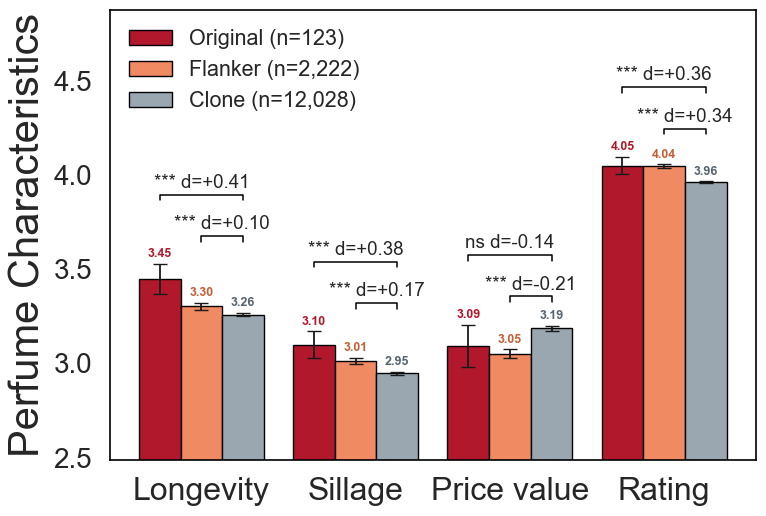

In [4]:
# Original vs Flanker vs Clone ratings
from scipy.stats import mannwhitneyu
from utils.utils import calculate_weighted_average
from collections import defaultdict
import seaborn as sns

WS_MIN = 286

_rat = pd.read_csv("../dataset/Fragrantica.csv",
                   usecols=['longevity_rating', 'sillage_rating', 'price_rating', 'rating', 'Total_votes', 'brand'])
for col in ['longevity_rating', 'sillage_rating', 'price_rating', 'rating']:
    df[col] = _rat[col].values
    calculate_weighted_average(df, col)
df['Total_votes'] = pd.to_numeric(_rat['Total_votes'], errors='coerce').values
df['brand'] = _rat['brand'].values

_refs = defaultdict(list)
for r, p in edges:
    _refs[int(p)].append(int(r))
_hn = [str(h).strip().lower() if isinstance(h, str) else None for h in df['brand'].values]
MIN_LIN = 5
def _root(n):
    seen = set()
    while n in parent and n not in seen:
        seen.add(n); n = parent[n]
    return n
size = {}
for n in set(parent) | set(parent.values()):
    r = _root(n); size[r] = size.get(r, 0) + 1
real = {r for r, s in size.items() if s >= MIN_LIN}
is_original = np.zeros(len(df), bool); is_original[list(real)] = True
is_flanker  = np.zeros(len(df), bool)
is_clone    = np.zeros(len(df), bool)
for p, rs in _refs.items():
    if is_original[p]:
        continue
    a = nsets[p]
    if not a:
        continue
    bj, br = -1.0, -1
    for r in rs:
        b = nsets[r]
        if b:
            j = len(a & b) / len(a | b)
            if j > bj:
                bj, br = j, r
    if br < 0:
        continue
    if _hn[p] is not None and _hn[br] is not None and _hn[p] == _hn[br]:
        is_flanker[p] = True
    else:
        is_clone[p] = True

ok = df['Total_votes'].values >= WS_MIN
GROUPS = [('Original', is_original & ok, '#b2182b'),
          ('Flanker',  is_flanker  & ok, '#ef8a62'),
          ('Clone',    is_clone    & ok, '#9aa7b1')]
TXTC = {'Original': '#b2182b', 'Flanker': '#c2603a', 'Clone': '#566571'}

METRICS = [('average_longevity_rating', 'Longevity'),
           ('average_sillage_rating',   'Sillage'),
           ('average_price_rating',     'Price value'),
           ('average_rating',           'Rating')]

def _stars(p):
    return '***' if p < 1e-3 else '**' if p < 1e-2 else '*' if p < 0.05 else 'ns'

def _cohen(a, b):
    sp = np.sqrt(((len(a)-1)*a.var(ddof=1) + (len(b)-1)*b.var(ddof=1)) / (len(a)+len(b)-2))
    return (a.mean() - b.mean()) / sp if sp > 0 else np.nan

res = []
for col, label in METRICS:
    vals  = {g: df.loc[m, col].dropna().values for g, m, _ in GROUPS}
    means = {g: v.mean() for g, v in vals.items()}
    cis   = {g: 1.96 * v.std(ddof=1)/np.sqrt(len(v)) for g, v in vals.items()}
    p_oc = mannwhitneyu(vals['Original'], vals['Clone'], alternative='two-sided').pvalue
    d_oc = _cohen(vals['Original'], vals['Clone'])
    p_fc = mannwhitneyu(vals['Flanker'], vals['Clone'], alternative='two-sided').pvalue
    d_fc = _cohen(vals['Flanker'], vals['Clone'])
    res.append(dict(label=label, means=means, cis=cis, p_oc=p_oc, d_oc=d_oc, p_fc=p_fc, d_fc=d_fc,
                    n={g: len(v) for g, v in vals.items()}))

print(" | ".join(f"{g}: {int(m.sum()):,}" for g, m, _ in GROUPS) + f"   (Total_votes >= {WS_MIN})\n")
print(f"{'metric':12s} {'Original':>9s} {'Flanker':>9s} {'Clone':>9s}  {'O-vs-C d':>9s} {'p(MWU)':>10s}")
for r in res:
    m = r['means']
    print(f"{r['label']:12s} {m['Original']:9.3f} {m['Flanker']:9.3f} {m['Clone']:9.3f}  "
          f"{r['d_oc']:9.2f} {r['p_oc']:10.2e}  {_stars(r['p_oc'])}")
print("\npairwise Mann-Whitney U (two-sided):")
for col, label in METRICS:
    vals = {g: df.loc[m, col].dropna().values for g, m, _ in GROUPS}
    pr = []
    for a, b in [('Original', 'Flanker'), ('Original', 'Clone'), ('Flanker', 'Clone')]:
        pp = mannwhitneyu(vals[a], vals[b], alternative='two-sided').pvalue
        pr.append(f"{a[:4]}-{b[:4]}: {_stars(pp)}")
    print(f"  {label:12s} " + " | ".join(pr))

top = sorted(real, key=lambda x: size[x], reverse=True)[:8]
print("\nExample Originals (by lineage size):")
for x in top:
    print(f"  {df.at[x,'perfume name'][:38]:38s} lineage={size[x]:3d} | long {df.at[x,'average_longevity_rating']:.2f} "
          f"sill {df.at[x,'average_sillage_rating']:.2f} price {df.at[x,'average_price_rating']:.2f} rating {df.at[x,'average_rating']:.2f}")

sns.set_theme(style="white", context="talk")
fig, ax = plt.subplots(figsize=(8, 5.5))
x = np.arange(len(res)); w = 0.27
offs = {'Original': -w, 'Flanker': 0.0, 'Clone': +w}
for g, m, color in GROUPS:
    ms  = [r['means'][g] for r in res]
    cis = [r['cis'][g]   for r in res]
    ax.bar(x + offs[g], ms, w, yerr=cis, color=color, edgecolor='black', linewidth=1.0,
           capsize=5, error_kw=dict(lw=1.3), label=f"{g} (n={int(m.sum()):,})")
    for xi, mm, ee in zip(x + offs[g], ms, cis):
        ax.text(xi, mm + ee + 0.02, f"{mm:.2f}", ha='center', va='bottom',
                fontsize=9, fontweight='bold', color=TXTC[g])

def _brk(xa, xb, y, p, d, xt):
    ax.plot([xa, xa, xb, xb], [y, y + 0.03, y + 0.03, y], color='black', lw=1.1)
    ax.text(xt, y + 0.045, f"{_stars(p)} d={d:+.2f}", ha='center', va='bottom', fontsize=13.5)
for i, r in enumerate(res):
    t = max(r['means'][g] + r['cis'][g] for g, _, _ in GROUPS)
    _brk(x[i] + 0.0, x[i] + w, t + 0.12, r['p_fc'], r['d_fc'], x[i] + w / 2)
    _brk(x[i] - w,   x[i] + w, t + 0.34, r['p_oc'], r['d_oc'], x[i])

lo = min(r['means'][g]-r['cis'][g] for r in res for g, _, _ in GROUPS)
hi = max(r['means'][g]+r['cis'][g] for r in res for g, _, _ in GROUPS)
ax.set_ylim(lo - 0.45, hi + 0.78)
ax.set_xticks(x); ax.set_xticklabels([r['label'] for r in res], fontsize=23)
ax.set_ylabel('Perfume Characteristics', fontsize=30)
plt.yticks(fontsize=20)

ax.legend(frameon=False, fontsize=15.5, loc='upper left', ncol=1)
for _sp in ax.spines.values():
    _sp.set_visible(True); _sp.set_color('black'); _sp.set_linewidth(1.2)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'Figure_3B.svg'), format='svg', dpi=300, bbox_inches='tight')
plt.show()

## Figure 3C: Are Perfumes Becoming Less Disruptive? (CD Index)

Reference: Park, Michael, Erin Leahey, and Russell J. Funk. "Papers and patents are becoming less disruptive over time." Nature 613.7942 (2023): 138-144.

"P reminds of R" link is treated as a citation. The CD_t index asks whether later perfumes recall a focal perfume instead of its predecessors (disruptive, CD to +1) or alongside them (consolidating, CD to -1), averaged by release year for windows t = 3, 5, 10. Built on the well-sampled, note-similar reminds-of network (`WEIGHTS_MIN = 286`, `J_MIN = J_TOP10`); the trend over time is the object of interest.

reminds links used: 7,670 / 245,185  (WEIGHTS_MIN=286, J_MIN=0.3157894736842105, DROP_VALUE_GE=None)
focal perfumes in network: 6,488 | with >=1 recorded predecessor: 69%
(focal, t) CD values: 9,827
    count   mean  median
t                       
3    3141  0.376    0.00
5    3573  0.413    0.25
10   3113  0.483    0.50


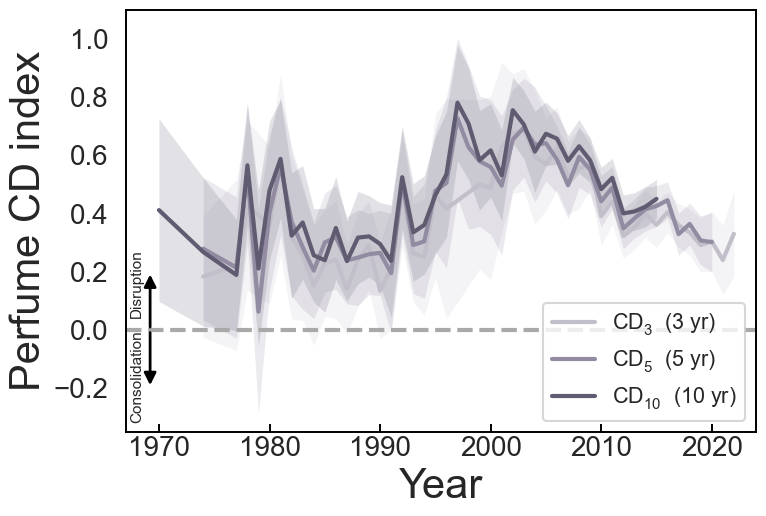

In [5]:
from collections import defaultdict
from utils.utils import parse_notes_weighted
import seaborn as sns

WEIGHTS_MIN   = 286
J_MIN         = J_TOP10
DROP_VALUE_GE = None
T_VALUES      = [3, 5, 10]
MIN_N, Y0     = 10, 1970

yr_all  = df['year'].values
val_all = df['value'].values
if 'Total_votes' not in df.columns:
    df['Total_votes'] = pd.to_numeric(
        pd.read_csv("../dataset/Fragrantica.csv", usecols=['Total_votes'])['Total_votes'], errors='coerce').values
ws = df['Total_votes'].values
keepw = (ws >= WEIGHTS_MIN) if WEIGHTS_MIN is not None else np.ones(len(df), bool)
nsets_cd = [set(parse_notes_weighted(s)) for s in df['notes']] if J_MIN > 0 else None

E = []
for r, p in edges:
    r, p = int(r), int(p)
    if not keepw[r] or not keepw[p]:
        continue
    if DROP_VALUE_GE is not None and not np.isnan(val_all[r]) and val_all[r] >= DROP_VALUE_GE:
        continue
    if J_MIN > 0:
        a, b = nsets_cd[r], nsets_cd[p]
        if not a or not b or len(a & b) / len(a | b) < J_MIN:
            continue
    E.append((r, p))
print(f"reminds links used: {len(E):,} / {len(edges):,}  "
      f"(WEIGHTS_MIN={WEIGHTS_MIN}, J_MIN={J_MIN}, DROP_VALUE_GE={DROP_VALUE_GE})")

citedby = defaultdict(list)
refs    = defaultdict(list)
for r, p in E:
    citedby[r].append(p)
    refs[p].append(r)
cb_nodes = {r: np.array(ps) for r, ps in citedby.items()}
cb_years = {r: yr_all[np.array(ps)] for r, ps in citedby.items()}

MAXY = np.nanmax(yr_all)
net  = set(citedby) | set(refs)
EMPTY = np.array([], dtype=int)

rows = []
for F in net:
    yF = yr_all[F]
    if np.isnan(yF):
        continue
    aN = cb_nodes.get(F, EMPTY); aY = cb_years.get(F, EMPTY)
    rF = refs.get(F, [])
    if rF:
        bN = np.concatenate([cb_nodes[r] for r in rF])
        bY = np.concatenate([cb_years[r] for r in rF])
    else:
        bN = EMPTY; bY = EMPTY
    for t in T_VALUES:
        if yF > MAXY - t:
            continue
        hi = yF + t
        A = set(aN[(aY > yF) & (aY <= hi)].tolist())
        B = set(bN[(bY > yF) & (bY <= hi)].tolist()) if bN.size else set()
        U = A | B
        if not U:
            continue
        cd = (len(A) - 2 * len(A & B)) / len(U)
        rows.append((int(yF), t, cd))

cd_df = pd.DataFrame(rows, columns=['year', 't', 'cd'])
frac_refs = np.mean([len(refs.get(F, [])) > 0 for F in net if not np.isnan(yr_all[F])]) if net else 0
print(f"focal perfumes in network: {len(net):,} | with >=1 recorded predecessor: {100*frac_refs:.0f}%")
print(f"(focal, t) CD values: {len(cd_df):,}")
print(cd_df.groupby('t')['cd'].agg(['count', 'mean', 'median']).round(3))

sns.set_theme(style="whitegrid", context="talk")
plt.figure(figsize=(8, 5.5))
cols = ['#c3bfca', '#928ba2', '#615b71']
for c, t in zip(cols, T_VALUES):
    g = cd_df[cd_df['t'] == t].groupby('year')['cd'].agg(['mean', 'count', 'std'])
    g = g[(g['count'] >= MIN_N) & (g.index >= Y0)]
    se = g['std'] / np.sqrt(g['count'])
    plt.fill_between(g.index, g['mean'] - 1.96 * se, g['mean'] + 1.96 * se, color=c, alpha=0.18, lw=0)
    plt.plot(g.index, g['mean'], color=c, linewidth=3, label=f'CD$_{{{t}}}$  ({t} yr)')
plt.axhline(0, color='darkgray', linewidth=3,linestyle='--')
plt.ylim(-0.25, plt.ylim()[1])
_xg = 1969.2
plt.annotate('', xy=(_xg, 0.20), xytext=(_xg, 0.0),
             arrowprops=dict(arrowstyle='-|>', color='black', lw=2.0, mutation_scale=18))
plt.annotate('', xy=(_xg, -0.20), xytext=(_xg, 0.0),
             arrowprops=dict(arrowstyle='-|>', color='black', lw=2.0, mutation_scale=18))
plt.text(_xg - 1.2, 0.16, 'Disruption', rotation=90, va='center', ha='center', fontsize=11)
plt.text(_xg - 1.2, -0.16, 'Consolidation', rotation=90, va='center', ha='center', fontsize=11)

plt.xlabel('Year', fontsize=30)
plt.ylabel('Perfume CD index', fontsize=30)
plt.xlim(1967, 2024)
plt.ylim(-0.35, 1.1)

plt.xticks(fontsize=20)
plt.tick_params(axis='x', which='both', bottom=True, length=6, width=1.4, color='black', direction='in')
plt.yticks(fontsize=20)
plt.grid(False)
for _sp in plt.gca().spines.values():
    _sp.set_visible(True); _sp.set_color('black'); _sp.set_linewidth(1.4)
plt.legend(frameon=True, fontsize=15.5)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'Figure_3C.svg'), format='svg', dpi=300)
plt.show()

## Cultural Selection by Imitation (Price Equation)

Fitness = how many later perfumes imitate a given one (its count of time-directed `this_perfume_reminds_ids` in-links). The selection differential for a trait z (note or accord) is S(z) = Cov(w, z) / mean(w): S > 0 means the trait is over-represented among copied perfumes (positively selected). Significance via a fitness-shuffle permutation null, FDR-corrected.

In [6]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from scipy import stats, sparse
from statsmodels.stats.multitest import multipletests
sys.path.append(os.path.abspath(".."))
from utils.utils import parse_notes
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'DejaVu Sans'],
                     'axes.linewidth': 1.1, 'xtick.direction': 'in', 'ytick.direction': 'in'})
OUT_DIR = "../output"; os.makedirs(OUT_DIR, exist_ok=True)

cols = ['perfume name', 'year', 'this_perfume_reminds_ids', 'id', 'price_rating', 'notes', 'accords']
df = pd.read_csv("../dataset/Fragrantica.csv", usecols=cols, low_memory=False)
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df['note_list'] = df['notes'].apply(parse_notes)

def _plist(s):
    try:
        v = json.loads(s) if isinstance(s, str) else []
        return v if isinstance(v, list) else []
    except Exception:
        return []
df['reminds'] = df['this_perfume_reminds_ids'].apply(_plist)

def _value(s):
    try:
        d = json.loads(s) if isinstance(s, str) else {}
        t = sum(d.values())
        return (sum(int(k) * v for k, v in d.items()) / t, t) if t > 0 else (np.nan, 0)
    except Exception:
        return (np.nan, 0)
vv = df['price_rating'].apply(_value); df['value'] = [x[0] for x in vv]; df['nvotes'] = [x[1] for x in vv]

def _accset(s):
    try:
        d = json.loads(s) if isinstance(s, str) else {}
        return {('floral' if k == 'white floral' else k) for k, v in d.items() if v > 0}
    except Exception:
        return set()
df['accord_set'] = df['accords'].apply(_accset)

id2idx = {int(pid): i for i, pid in enumerate(df['id'])}

yr = df['year'].values
edges = []
for p, rem in enumerate(df['reminds']):
    yp = yr[p]
    if np.isnan(yp):
        continue
    for rname in rem:
        r = id2idx.get(int(rname))
        if r is not None and not np.isnan(yr[r]) and yp > yr[r]:
            edges.append((r, p))
edges = np.array(edges)
val_arr = df['value'].values

fit = Counter(edges[:, 0].tolist())
df['fitness'] = [fit.get(i, 0) for i in range(len(df))]
vgpos = np.nan_to_num(np.maximum(val_arr[edges[:, 1]] - val_arr[edges[:, 0]], 0.0))
fitv = Counter()
for (r, _p), g in zip(edges, vgpos):
    fitv[r] += g
df['fitness_v'] = [fitv.get(i, 0.0) for i in range(len(df))]
FW = 10
fitfw = Counter()
for r, p in edges:
    if 0 < yr[p] - yr[r] <= FW:
        fitfw[r] += 1
df['fitness_fw'] = [fitfw.get(i, 0) for i in range(len(df))]

print(f"time-directed copy edges: {len(edges):,} | perfumes copied (fitness>0): {(df['fitness']>0).sum():,}")
print("\nMost-copied originals (fitness = # later imitators):")
print(df.nlargest(8, 'fitness')[['perfume name', 'year', 'fitness', 'value']].to_string(index=False))
gr, gp = val_arr[edges[:, 0]], val_arr[edges[:, 1]]
m = ~(np.isnan(gr) | np.isnan(gp)); gap = gp[m] - gr[m]
print(f"\nValidation - value-gap (copy - original): mean {gap.mean():+.3f}, "
      f"{100*(gap>0).mean():.0f}% of edges positive (copy cheaper, as expected)")

time-directed copy edges: 245,185 | perfumes copied (fitness>0): 32,603

Most-copied originals (fitness = # later imitators):
      perfume name   year  fitness    value
           Aventus 2010.0      612 1.688786
Baccarat Rouge 540 2015.0      562 1.967872
        Light Blue 2001.0      500 2.958521
  La Vie Est Belle 2012.0      411 2.846911
      Pname_003813 1996.0      390 2.997399
      Pname_032025 1996.0      381 3.855469
      Pname_111067 2011.0      358 2.113089
    Terre d Hermes 2006.0      337 3.044369

Validation - value-gap (copy - original): mean +0.130, 55% of edges positive (copy cheaper, as expected)


## Figures 3D, 3E: Per-era selection map

Top row (3D): per era, the green ring's area = the fraction of notes under significant copy-selection (FDR < 0.05); notes inside the ring are colored by S (red = over-copied, blue = under), outside = drift (grey); angle = olfactory family, size = prevalence. Bottom row (3E): for the FDR-significant notes, copy-selection S vs the in-era prevalence trend, with Spearman rho. Three 20-year eras: 1965-1984, 1985-2004, 2005-2024.

Total_votes cutoff: no cutoff (full set)  ->  92,589/92,589 perfumes used as selection-differential parents (copy-fitness always counted over ALL perfumes).
sector accords: ['woody', 'floral', 'citrus', 'sweet', 'fruity', 'amber', 'aromatic', 'warm spicy', 'musky', 'vanilla', 'green']
notes in 'Other' (long tail of minor accords): 813 of 1553
note->family: {'Rose': 'floral', 'Cedar': 'woody', 'Bergamot': 'citrus', 'Vanilla': 'vanilla', 'Musk': 'floral', 'Jasmine': 'floral', 'Patchouli': 'Other', 'Sandalwood': 'woody', 'Lemon': 'citrus', 'Oud': None}


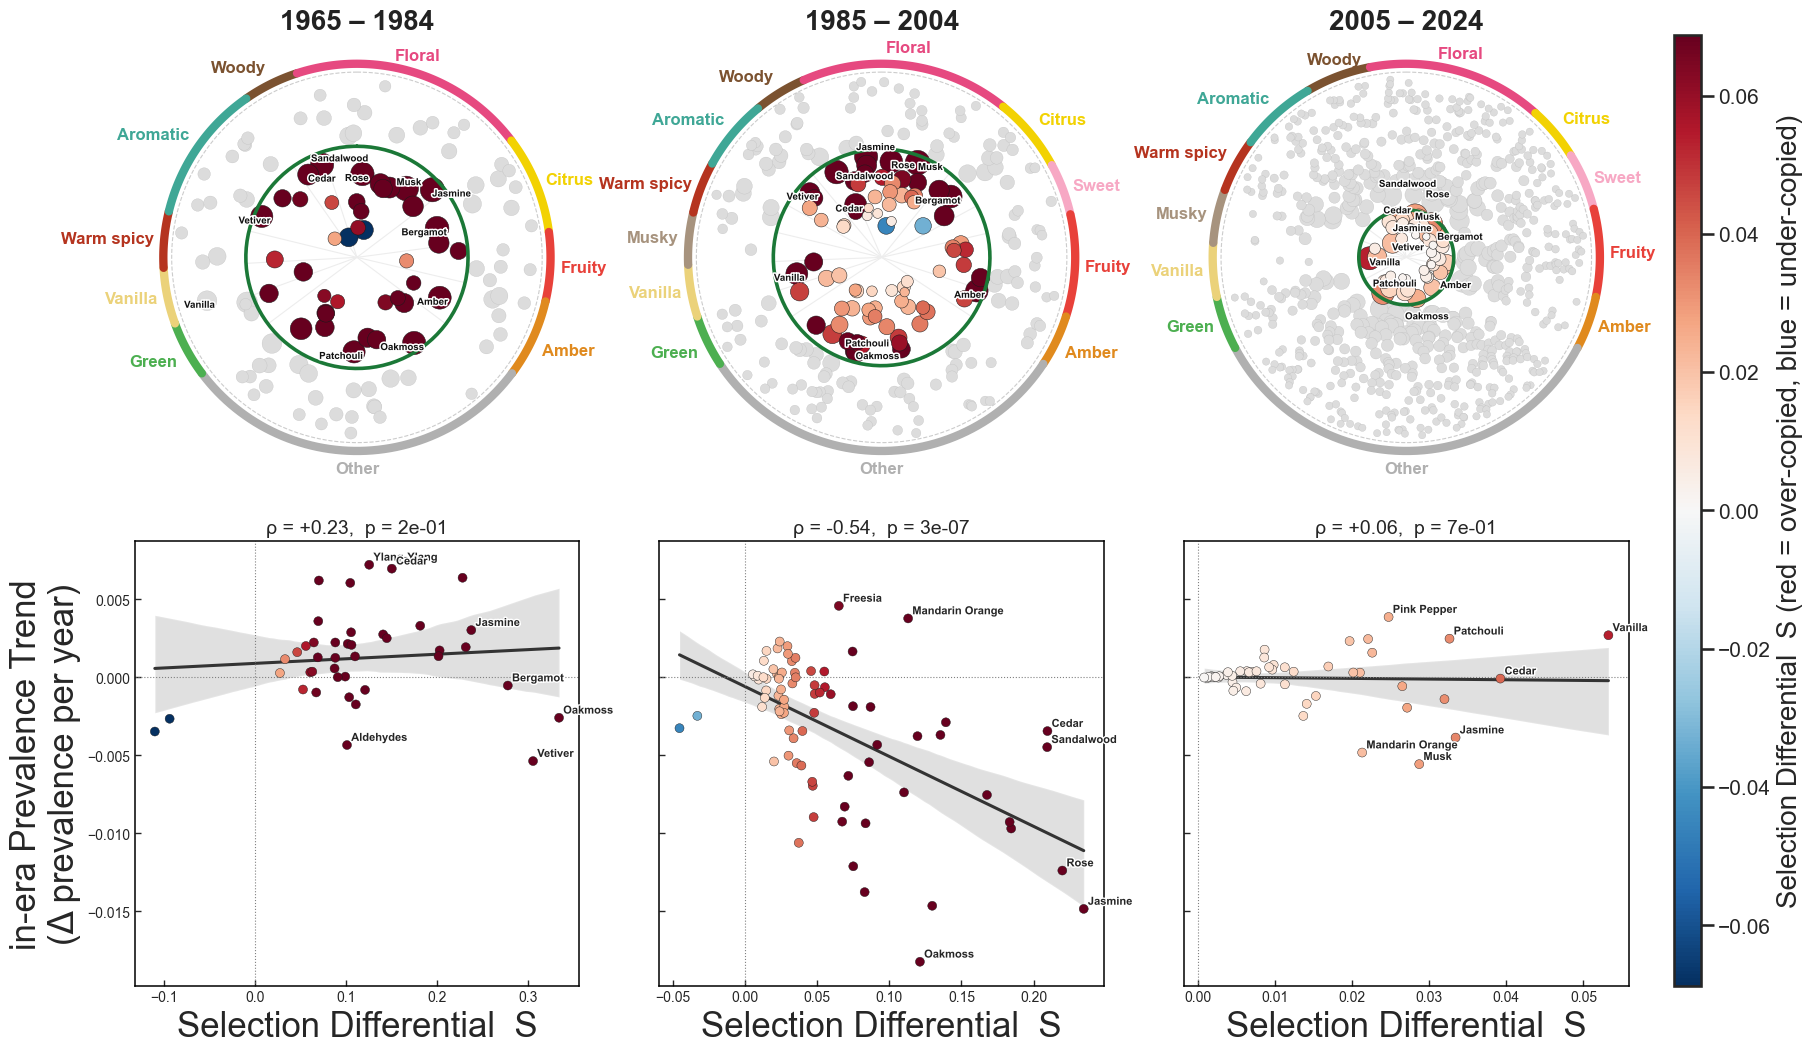

Compass - fraction of notes under selection (FDR < 0.05), bootstrap 95% CI:
  1965 – 1984:    36%  [32-47]    (N=1,260, notes=114, under selection=41, core mean S=+0.113)
  1985 – 2004:    34%  [31-40]    (N=5,485, notes=234, under selection=80, core mean S=+0.058)
  2005 – 2024:     7%  [7-11]    (N=67,889, notes=746, under selection=49, core mean S=+0.013)

Validation - Spearman rho(S, in-era prevalence trend), FDR-significant notes:
  1965 – 1984:  rho=+0.23,  p=1.6e-01    (n=41)
  1985 – 2004:  rho=-0.54,  p=3.0e-07    (n=80)
  2005 – 2024:  rho=+0.06,  p=7.0e-01    (n=49)


In [7]:
from matplotlib.colors import TwoSlopeNorm
from collections import defaultdict
from scipy import sparse, stats
from statsmodels.stats.multitest import multipletests
import matplotlib.patheffects as pe
from utils.utils import parse_notes_weighted
from statsmodels.nonparametric.smoothers_lowess import lowess
from collections import Counter

WEIGHTS_MIN = None
if 'Total_votes' not in df.columns:
    df['Total_votes'] = pd.to_numeric(
        pd.read_csv("../dataset/Fragrantica.csv", usecols=['Total_votes'])['Total_votes'],
        errors='coerce').values
_pmask = (df['Total_votes'] >= WEIGHTS_MIN) if WEIGHTS_MIN is not None else pd.Series(True, index=df.index)
_lbl = 'no cutoff (full set)' if WEIGHTS_MIN is None else f'>= {WEIGHTS_MIN}'
print(f"Total_votes cutoff: {_lbl}  ->  {int(_pmask.sum()):,}/{len(df):,} perfumes used as "
      f"selection-differential parents (copy-fitness always counted over ALL perfumes).")

if 'note_w' not in df.columns:
    df['note_w'] = df['notes'].apply(lambda s: list(parse_notes_weighted(s)))

_FLORAL = {'white floral', 'yellow floral', 'rose'}
def _ad(s):
    try:
        d = json.loads(s) if isinstance(s, str) else {}
        out = {}
        for k, v in d.items():
            kk = 'floral' if k in _FLORAL else k
            out[kk] = out.get(kk, 0.0) + float(v)
        return out
    except Exception:
        return {}
_gsum = defaultdict(float); _gn = 0
_nsum = defaultdict(lambda: defaultdict(float)); _ncnt = defaultdict(int)
for nl, accs in zip(df['note_list'], df['accords']):
    ad = _ad(accs)
    if not ad:
        continue
    _gn += 1
    for a, w in ad.items():
        _gsum[a] += w
    for nm in set(nl):
        _ncnt[nm] += 1
        for a, w in ad.items():
            _nsum[nm][a] += w
_gmean = {a: _gsum[a] / _gn for a in _gsum}
_floor = 0.05 * max(_gmean.values())
def _classify(nm):
    d = _nsum.get(nm)
    if not d:
        return 'Other'
    return max(d, key=lambda a: (d[a] / _ncnt[nm]) / np.sqrt(max(_gmean.get(a, _floor), _floor)))
note_acc = {nm: _classify(nm) for nm in _nsum}
DISPLAY = ['woody', 'floral', 'citrus', 'sweet', 'fruity', 'amber', 'aromatic',
           'warm spicy', 'musky', 'vanilla', 'green']
note_fam_c = {nm: (a if a in DISPLAY else 'Other') for nm, a in note_acc.items()}
_nother = sum(v == 'Other' for v in note_fam_c.values())
print(f"sector accords: {DISPLAY}")
print(f"notes in 'Other' (long tail of minor accords): {_nother} of {len(note_fam_c)}")
print("note->family:", {nm: note_fam_c.get(nm) for nm in
      ['Rose', 'Cedar', 'Bergamot', 'Vanilla', 'Musk', 'Jasmine', 'Patchouli', 'Sandalwood', 'Lemon', 'Oud']})
_top_acc = [a for a in DISPLAY if a in set(note_fam_c.values())]
_half = (len(_top_acc) + 1) // 2
_sector = _top_acc[:_half] + ['Other'] + _top_acc[_half:][::-1]
ACCORD_COLORS = {'woody': '#7b5230', 'floral': '#e64980', 'citrus': '#f2d202', 'sweet': '#f7a8c4',
                 'fruity': '#e8413a', 'amber': '#e08a1e', 'aromatic': '#3fa796', 'warm spicy': '#b5341f',
                 'musky': '#a7937e', 'vanilla': '#ebd27a', 'green': '#4caf50', 'Other': '#b0b0b0'}
_acol = {a: ACCORD_COLORS.get(a, '#888888') for a in _top_acc}; _acol['Other'] = ACCORD_COLORS['Other']
R_OUT = 10.0

from collections import defaultdict as _dd
_yrv = df['year'].values
_copyyears = _dd(list)
for _r, _p in edges:
    _copyyears[int(_r)].append(_yrv[int(_p)])
_copyyears = {r: np.sort(np.array(v)) for r, v in _copyyears.items()}
def _fit_within(i, y_end):
    ys = _copyyears.get(i)
    return 0 if ys is None else int(np.searchsorted(ys, y_end + 1e-6))

def _analytic_S_p(w, Zk, N):
    W = w.sum()
    if W <= 0 or Zk.shape[1] == 0:
        return np.zeros(Zk.shape[1]), np.ones(Zk.shape[1])
    cnt = np.asarray(Zk.sum(0)).ravel(); raw = cnt / N
    S = np.asarray(w @ Zk).ravel() / W - raw
    varS = cnt * (N - cnt) / max(N - 1, 1) * w.var() / (W ** 2)
    z = np.divide(S, np.sqrt(varS), out=np.zeros_like(S), where=varS > 0)
    return S, 2 * stats.norm.sf(np.abs(z))

def era_selection(y0, y1, min_count=10, n_boot=1000, seed=0):
    sub = df[(df['year'] >= y0) & (df['year'] <= y1) & (df['note_w'].map(len) > 0) & _pmask]
    nls = sub['note_w'].tolist(); w = np.array([_fit_within(ii, y1) for ii in sub.index], dtype=float); N = len(sub)
    idx = {}; rows = []; cls = []
    for i, nl in enumerate(nls):
        for nm in set(nl):
            j = idx.setdefault(nm, len(idx)); rows.append(i); cls.append(j)
    Z = sparse.csr_matrix((np.ones(len(rows)), (rows, cls)), shape=(N, len(idx)))
    items = [None] * len(idx)
    for nm, j in idx.items():
        items[j] = nm
    cnt = np.asarray(Z.sum(0)).ravel(); keep = cnt >= min_count
    Zk = Z[:, keep].tocsr(); itemsk = [it for it, k in zip(items, keep) if k]; cntk = cnt[keep]
    raw = cntk / N
    S, p = _analytic_S_p(w, Zk, N)
    q = multipletests(p, method='fdr_bh')[1] if len(p) else np.array([])
    rng = np.random.default_rng(seed); fr = []
    for _ in range(n_boot):
        ix = rng.integers(0, N, N)
        _, pb = _analytic_S_p(w[ix], Zk[ix], N)
        fr.append(100 * np.mean(multipletests(pb, method='fdr_bh')[1] < 0.05) if len(pb) else 0.0)
    ci = (float(np.percentile(fr, 2.5)), float(np.percentile(fr, 97.5))) if fr else (float('nan'), float('nan'))
    trend = np.full(len(itemsk), np.nan)
    if Zk.shape[1]:
        _yi = sub['year'].values.astype(int); _P = []; _tt = []
        for t in np.array(sorted(set(_yi))):
            ix_t = np.where(_yi == t)[0]
            if len(ix_t) >= 10:
                _P.append(np.asarray(Zk[ix_t].sum(0)).ravel() / len(ix_t)); _tt.append(float(t))
        if len(_tt) >= 4:
            _P = np.array(_P); _tt = np.array(_tt); _span = _tt[-1] - _tt[0]
            _frl = min(0.8, max(0.5, 15.0 / len(_tt)))
            if _span > 0:
                for j in range(Zk.shape[1]):
                    _ys = lowess(_P[:, j], _tt, frac=_frl, return_sorted=True)[:, 1]
                    trend[j] = (_ys[-1] - _ys[0]) / _span
    d = pd.DataFrame({'note': itemsk, 'n': cntk.astype(int), 'prev': raw, 'S': S, 'p': p, 'q': q, 'trend': trend})
    d = d.sort_values('prev', ascending=False).reset_index(drop=True)
    d['fam'] = d['note'].map(lambda x: note_fam_c.get(x, 'Other'))
    return d, N, ci

def draw_compass(ax, d, era, labels, norm, ci=None):
    d = d.copy(); d['famx'] = np.where(d['fam'].isin(_top_acc), d['fam'], 'Other')
    active = [s for s in _sector if (d['famx'] == s).any()]
    cnt = Counter(d['famx'])
    _wfrac = {s: max(cnt[s] / len(d), 0.05) for s in active}
    _wtot = sum(_wfrac.values())
    wd = {s: _wfrac[s] / _wtot * 2 * np.pi for s in active}
    io = active.index('Other') if 'Other' in active else len(active) // 2
    before = sum(wd[active[j]] for j in range(io))
    start = np.pi - before - wd[active[io]] / 2
    sel = (d['q'] < 0.05).values; f = sel.mean(); rb = R_OUT * np.sqrt(f)
    secr = {}; cur = start
    for s in active:
        secr[s] = (cur, cur + wd[s]); cur += wd[s]
    _Smin = np.nanmin(d['S'].values); _Srng = np.nanmax(d['S'].values) - _Smin
    Sn = (d['S'].values - _Smin) / (_Srng + 1e-9)
    Pn = d['prev'].values / max(d['prev'].max(), 1e-9)
    sel_score = 0.5 * Sn + 0.5 * Pn
    ra = np.random.default_rng(7)
    theta = np.zeros(len(d)); rad = np.zeros(len(d))

    def _refl(v, lo, hi):
        span = hi - lo
        if span <= 1e-9:
            return np.full(len(v), 0.5 * (lo + hi))
        t = (v - lo) % (2 * span)
        return lo + np.where(t > span, 2 * span - t, t)

    def _fill(M, a0, a1, r0, r1):
        pa = 0.015 * (a1 - a0); pr = 0.02 * (r1 - r0)
        th = ra.uniform(a0 + pa, a1 - pa, M)
        rr = np.sqrt(ra.uniform((r0 + pr) ** 2, (r1 - pr) ** 2, M))
        return th, rr

    for s in active:
        a0, a1 = secr[s]; pad = 0.05 * (a1 - a0)
        for band in (True, False):
            ix = np.where((d['famx'].values == s) & (sel == band))[0]
            M = len(ix)
            if M == 0:
                continue
            r0, r1 = (1.0, max(rb - 0.2, 1.4)) if band else (rb + 0.25, R_OUT - 0.2)
            th_s, rr_s = _fill(M, a0 + pad, a1 - pad, r0, r1)
            slot_by_r = np.argsort(rr_s)
            sc = sel_score if band else Pn
            note_by_imp = ix[np.argsort(-sc[ix])]
            slots = slot_by_r[::-1] if band else slot_by_r
            for n, sl in zip(note_by_imp, slots):
                theta[n] = th_s[sl]; rad[n] = rr_s[sl]
    sizes = 15 + 300 * (d['prev'].values / d['prev'].max()) ** 0.4
    rings = np.linspace(0, 2 * np.pi, 200)
    ax.plot(rings, [R_OUT] * 200, color='#cccccc', lw=0.8, ls='--', zorder=1)
    for s in active:
        a0, _ = secr[s]
        ax.plot([a0, a0], [0, rb], color='#ededed', lw=0.8, zorder=0)
    ax.scatter(theta[~sel], rad[~sel], s=sizes[~sel], color='#dcdcdc', edgecolors='#bbbbbb', linewidths=0.2, zorder=2)
    sc = ax.scatter(theta[sel], rad[sel], c=d['S'].values[sel], cmap='RdBu_r', norm=norm, s=sizes[sel],
                    edgecolors='k', linewidths=0.35, zorder=3)
    ax.plot(rings, [rb] * 200, color='#1b7837', lw=2.6, zorder=4)
    for s in active:
        a0, a1 = secr[s]; mid = (a0 + a1) / 2; arc = np.linspace(a0, a1, 60)
        ax.plot(arc, [R_OUT + 0.45] * 60, color=_acol.get(s, '#888'), lw=6, solid_capstyle='round', zorder=3)
        ox, oy = np.sin(mid), np.cos(mid)
        ha = 'left' if ox > 0.4 else 'right' if ox < -0.4 else 'center'
        va = 'bottom' if oy > 0.4 else 'top' if oy < -0.4 else 'center'
        ax.text(mid, R_OUT + 1.0, s.capitalize(), fontsize=12, fontweight='bold',
                color=_acol.get(s, '#888'), ha=ha, va=va, zorder=4)
    nm2i = {nm: i for i, nm in enumerate(d['note'])}
    lab_texts = []
    for nm in labels:
        if nm in nm2i:                      
            i = nm2i[nm]
            lab_texts.append(ax.text(theta[i], rad[i], nm, fontsize=7, ha='center', va='center', zorder=8,
                                     color='#111111', fontweight='bold',
                                     path_effects=[pe.withStroke(linewidth=2.2, foreground='white')]))
    try:                                     
        from adjustText import adjust_text
        adjust_text(lab_texts, ax=ax, arrowprops=dict(arrowstyle='-', color='0.5', lw=0.5))
    except Exception:
        pass
    _cit = f"  [{ci[0]:.0f}\u2013{ci[1]:.0f}]" if ci else ""
    ax.text(0, R_OUT + 2.7, f"{era}", fontsize=20, ha='center', va='center', fontweight='bold', color='#222')
    ax.set_ylim(0, R_OUT + 2.0); ax.set_yticks([]); ax.set_xticks([]); ax.grid(False)
    ax.spines['polar'].set_visible(False)
    return sc

import seaborn as sns
sns.set_theme(style="white", context="talk")
plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial', 'DejaVu Sans']})
eras_c = [('1965 – 1984', 1965, 1984), ('1985 – 2004', 1985, 2004),
          ('2005 – 2024', 2005, 2024)]
core_lab = ['Musk', 'Vanilla', 'Amber', 'Bergamot', 'Cedar', 'Rose', 'Sandalwood', 'Jasmine', 'Patchouli', 'Vetiver', 'Oakmoss']
tabs = [era_selection(y0, y1) for _, y0, y1 in eras_c]
allS = np.concatenate([t[0]['S'].values for t in tabs]); smax = max(np.nanpercentile(np.abs(allS), 95), 0.01)
norm = TwoSlopeNorm(vmin=-smax, vcenter=0.0, vmax=smax)

sig_data = []
for (lab, y0, y1), (d, N, ci) in zip(eras_c, tabs):
    mm = d[d['q'] < 0.05].dropna(subset=['trend'])
    rho1, p1 = stats.spearmanr(mm['S'], mm['trend']) if len(mm) >= 5 else (np.nan, np.nan)
    sig_data.append((mm, rho1, p1))
_alt = np.concatenate([m['trend'].values for m, _, _ in sig_data if len(m)])
_yp = 0.06 * (np.nanmax(_alt) - np.nanmin(_alt)); ylo, yhi = np.nanmin(_alt) - _yp, np.nanmax(_alt) + _yp

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 3, left=0.05, right=0.88, top=0.96, bottom=0.07, wspace=0.18, hspace=-0.1)
axc = axs = None
for i, ((lab, y0, y1), (d, N, ci)) in enumerate(zip(eras_c, tabs)):
    axc = fig.add_subplot(gs[0, i], projection='polar'); axc.set_theta_zero_location('N'); axc.set_theta_direction(-1)
    draw_compass(axc, d, lab, core_lab, norm)
    axs = fig.add_subplot(gs[1, i])
    mm, rho1, p1 = sig_data[i]
    if len(mm):
        sns.regplot(x='S', y='trend', data=mm, ax=axs, scatter=False, ci=95, line_kws=dict(color='#333333', lw=2.2))
        axs.scatter(mm['S'], mm['trend'], c=mm['S'], cmap='RdBu_r', norm=norm, s=42, edgecolors='k', linewidths=0.3, zorder=3)
        axs.axhline(0, color='grey', lw=0.8, ls=':'); axs.axvline(0, color='grey', lw=0.8, ls=':')
        _l = pd.concat([mm.nlargest(4, 'S'), mm.nlargest(2, 'trend'), mm.nsmallest(2, 'trend')]).drop_duplicates('note')
        for _, r in _l.iterrows():
            axs.annotate(r['note'], (r['S'], r['trend']), fontsize=8, fontweight='bold',
                         xytext=(3, 3), textcoords='offset points',
                         path_effects=[pe.withStroke(linewidth=2.0, foreground='white')])
    axs.set_ylim(ylo, yhi); axs.set_box_aspect(1)
    axs.set_title(f"ρ = {rho1:+.2f}" + (f",  p = {p1:.0e}" if np.isfinite(p1) else ""), fontsize=14, fontweight='normal')
    axs.set_xlabel('Selection Differential  S', fontsize=25)
    axs.set_ylabel('in-era Prevalence Trend\n(Δ prevalence per year)' if i == 0 else '', fontsize=25)
    axs.tick_params(direction='in', length=4, width=1.0, bottom=True, left=True, labelleft=(i == 0), labelsize=10)
    for _sp in axs.spines.values():
        _sp.set_visible(True); _sp.set_color('black'); _sp.set_linewidth(1.1)

_ptop = axc.get_position(); _pbot = axs.get_position()
cax = fig.add_axes([0.905, _pbot.y0, 0.015, _ptop.y1 - _pbot.y0])
_smap = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm); _smap.set_array([])
cb = fig.colorbar(_smap, cax=cax); cb.set_label('Selection Differential  S (red = over-copied, blue = under-copied)', fontsize=20)
cb.ax.tick_params(labelsize=15)
plt.savefig(os.path.join(OUT_DIR, 'Figure_3DE.svg'), format='svg', dpi=300, bbox_inches='tight')
plt.show()

print("Compass - fraction of notes under selection (FDR < 0.05), bootstrap 95% CI:")
for (lab, y0, y1), (d, N, ci) in zip(eras_c, tabs):
    sel = d['q'] < 0.05; _cm = d[sel]['S'].mean() if sel.any() else float('nan')
    print(f"  {lab}:  {100*sel.mean():4.0f}%  [{ci[0]:.0f}-{ci[1]:.0f}]    (N={N:,}, notes={len(d)}, under selection={int(sel.sum())}, core mean S={_cm:+.3f})")
print("\nValidation - Spearman rho(S, in-era prevalence trend), FDR-significant notes:")
for (lab, y0, y1), (mm, rho1, p1) in zip(eras_c, sig_data):
    print(f"  {lab}:  rho={rho1:+.2f},  p={p1:.1e}    (n={len(mm)})")

## Figure S9: copy lineage network (Top 10 Originals)

Same lineage-tree construction as Figure 3A, extended to the top 10 Originals (`K_TREES = 10`).

Original lineages: ['Chanel No 5', 'Aventus', 'Ex cla ma tion', 'Aloha Tiare', 'Gentleman 1974', 'Fracas', 'Viva la Juicy', 'Light Blue', 'Diva', 'L Air du Temps']
secondary (two-parent) merge links drawn: 82
tree nodes: 10 Original(s) | 203 clones (diff house) | 45 flankers (same house)


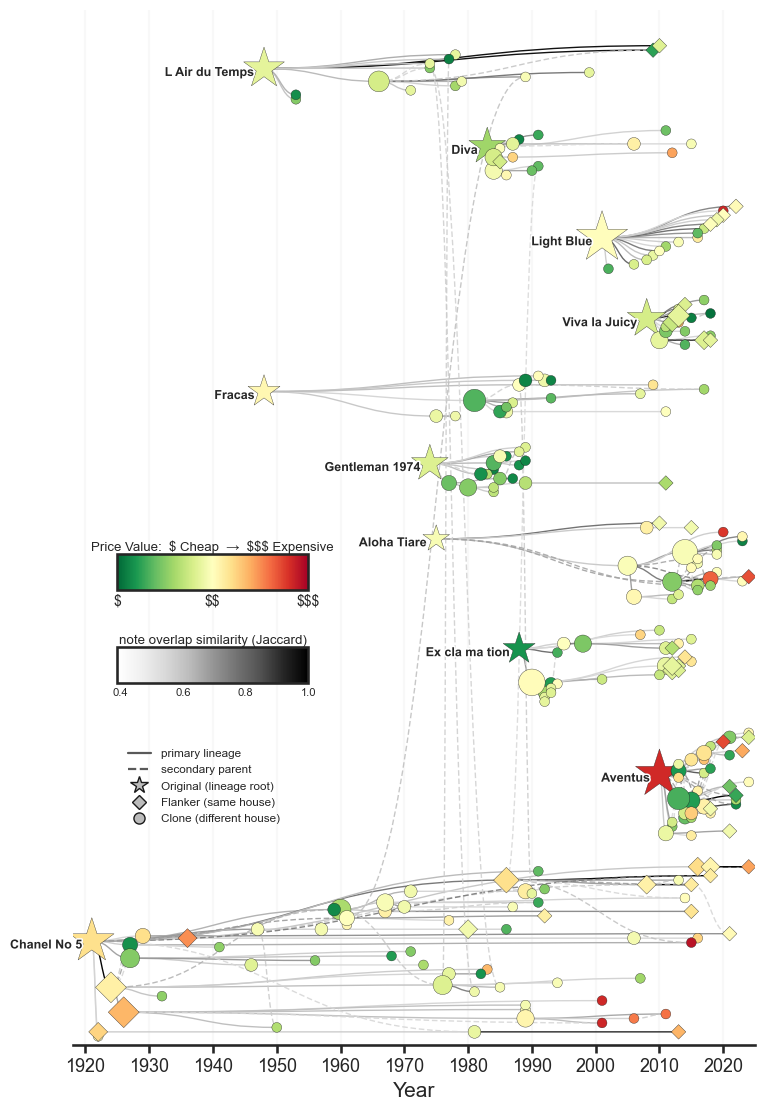

In [8]:
import sys as _sys, json, re
import networkx as nx
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.path import Path
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from collections import defaultdict

J_MIN = J_TOP5
SEC_MIN = J_TOP5
GREAT_VALUE = 5.0
K_TREES = 10
yr = df['year'].values; val = df['value'].values

def _value_median(s):
    try:
        d = {int(k): v for k, v in (json.loads(s) if isinstance(s, str) else {}).items()}
    except Exception:
        return np.nan
    N = sum(d.values())
    if N <= 0:
        return np.nan
    half, cum = N / 2.0, 0
    for k in (1, 2, 3, 4, 5):
        f = d.get(k, 0)
        if cum + f >= half:
            return (k - 0.5) + (half - cum) / f if f > 0 else float(k)
        cum += f
    return 5.0
pval = df['price_rating'].apply(_value_median).values

def _clean(nm):
    nm = re.sub(r'\s+(Extrait de Parfum|Eau de Parfum|Eau de Toilette|Eau de Cologne|Parfum|Cologne|Elixir|EDP|EDT)\b.*$', '', str(nm)).strip()
    t = nm.split()
    for k in range(min(4, len(t) // 2), 0, -1):
        if t[:k] == t[-k:] and len(t) > k:
            nm = " ".join(t[:-k]); break
    return nm.strip()

def _term(i):
    return (not np.isnan(val[i])) and (val[i] >= GREAT_VALUE)

in_edges = defaultdict(list)
for r, p in edges:
    r, p = int(r), int(p)
    if _term(r) or not keep[r] or not keep[p]:
        continue
    a, b = nsets[r], nsets[p]
    if not a or not b:
        continue
    j = len(a & b) / len(a | b)
    if j >= J_MIN:
        in_edges[p].append((j, r))
allpar = {p: sorted(lst, reverse=True) for p, lst in in_edges.items()}
parent = {p: lp[0][1] for p, lp in allpar.items()}
pj = {p: lp[0][0] for p, lp in allpar.items()}
secondary = {p: lp[1] for p, lp in allpar.items() if len(lp) >= 2 and lp[1][0] >= SEC_MIN}

T = nx.DiGraph()
for p, par in parent.items():
    T.add_edge(par, p, w=pj[p])
trees = sorted(nx.weakly_connected_components(T), key=len, reverse=True)[:K_TREES]

_sys.setrecursionlimit(10000)
def _tidy(root, children):
    local, c = {}, [0]
    def rec(n):
        ch = sorted(children.get(n, []), key=lambda x: yr[x])
        if not ch:
            local[n] = c[0]; c[0] += 1
        else:
            for x in ch:
                rec(x)
            local[n] = float(np.mean([local[x] for x in ch]))
    rec(root)
    return local, c[0]

vnorm = Normalize(1, 5); vcmap = plt.cm.RdYlGn
jnorm = Normalize(J_MIN, 1.0); ecmap = plt.cm.Greys
pos, roots, subTs = {}, [], []
offset = 0.0; GAP = 6.0
for comp in trees:
    Tc = T.subgraph(comp).copy(); subTs.append(Tc)
    root = next(n for n in Tc if Tc.in_degree(n) == 0); roots.append(root)
    ch = defaultdict(list)
    for u, v in Tc.edges:
        ch[u].append(v)
    local, h = _tidy(root, ch)
    for n in Tc.nodes:
        pos[n] = (yr[n], offset + local[n])
    offset += h + GAP
disp = set(pos)

def _bezier(ax, u, v, w, ls, alpha):
    x0, y0 = pos[u]; x1, y1 = pos[v]; dx = (x1 - x0) or 0.5
    verts = [(x0, y0), (x0 + 0.5 * dx, y0), (x0 + 0.5 * dx, y1), (x1, y1)]
    ax.add_patch(mpatches.PathPatch(
        Path(verts, [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]),
        fc='none', ec=ecmap(0.25 + 0.75 * jnorm(w)), lw=1, ls=ls, alpha=1.1*alpha, zorder=1))

total_rows = offset
fig, ax = plt.subplots(figsize=(8, max(5, total_rows * 0.05)))
for Tc in subTs:
    for u, v in Tc.edges:
        _bezier(ax, u, v, Tc[u][v]['w'], '-', 0.9)
n_sec = 0
for p, (j, r) in secondary.items():
    if p in disp and r in disp and r != parent[p]:
        _bezier(ax, r, p, j, (0, (4, 2)), 0.8); n_sec += 1
print(f"Original lineages: {[_clean(df.at[rt,'perfume name']) for rt in roots]}")
print(f"secondary (two-parent) merge links drawn: {n_sec}")

alln = [n for Tc in subTs for n in Tc.nodes]
if 'brand' not in df.columns:
    df['brand'] = pd.read_csv("../dataset/Fragrantica.csv", usecols=['brand'])['brand'].values
_hn = [str(h).strip().lower() if isinstance(h, str) else None for h in df['brand'].values]
root_set = set(roots)
def _node_kind(n):
    if n in root_set:
        return 'orig'
    p = parent.get(n)
    if p is not None and _hn[n] is not None and _hn[n] == _hn[p]:
        return 'flank'
    return 'clone'
_grp = {'orig': [], 'clone': [], 'flank': []}
for n in alln:
    _grp[_node_kind(n)].append(n)
_MK = {'orig': '*', 'clone': 'o', 'flank': 'D'}
_SZ = {'orig': 2.6, 'clone': 1.0, 'flank': 1.1}
_NODE_SCALE = 2.5
for _k, _ns in _grp.items():
    if not _ns:
        continue
    ax.scatter([pos[n][0] for n in _ns], [pos[n][1] for n in _ns], marker=_MK[_k],
               c=[vcmap(vnorm(pval[n])) if not np.isnan(pval[n]) else '#cccccc' for n in _ns],
               s=[_NODE_SCALE * _SZ[_k] * (20 + 14 * T.out_degree(n)) for n in _ns],
               edgecolors='k', linewidths=0.25, zorder=3)
print(f"tree nodes: {len(_grp['orig'])} Original(s) | {len(_grp['clone'])} clones (diff house) | "
      f"{len(_grp['flank'])} flankers (same house)")
for rt in roots:
    ax.text(yr[rt] - 1.5, pos[rt][1]-1, _clean(df.at[rt, 'perfume name'])[:24], fontsize=9,
            ha='right', va='center', fontweight='bold',
            path_effects=[pe.withStroke(linewidth=2.2, foreground='white')], zorder=5)

yy = [int(yr[n]) for n in alln]; lo, hi = min(yy), max(yy)
ticks = list(range(lo - lo % 10, 2021, 10))
ax.set_xlim(lo - 3, hi + 1); ax.set_ylim(-2, total_rows + 1)
ax.set_yticks([]); ax.set_xticks(ticks); ax.set_xticklabels([str(t) for t in ticks])
ax.tick_params(axis='x', bottom=True, labelbottom=True, labelsize=13, length=6)
ax.set_xlabel('Year', fontsize=15); ax.grid(axis='x', alpha=0.12)
for sp in ['top', 'right', 'left']:
    ax.spines[sp].set_visible(False)

sm_p = plt.cm.ScalarMappable(norm=vnorm, cmap=vcmap); sm_p.set_array([])
cax_p = ax.inset_axes([0.065, 0.44, 0.28, 0.035])
cb_p = fig.colorbar(sm_p, cax=cax_p, orientation='horizontal')
cb_p.set_ticks([1, 3, 5]); cb_p.set_ticklabels([r'\$\$\$', r'\$\$', r'\$'])
cb_p.ax.invert_xaxis()
cb_p.ax.tick_params(labelsize=10, length=0)
cb_p.ax.set_title(r'Price Value:  \$ Cheap  →  \$\$\$ Expensive', fontsize=9.5, pad=2)

sm_j = plt.cm.ScalarMappable(norm=jnorm, cmap=ecmap); sm_j.set_array([])
cax_j = ax.inset_axes([0.065, 0.35, 0.28, 0.035])
cb_j = fig.colorbar(sm_j, cax=cax_j, orientation='horizontal')
cb_j.ax.tick_params(labelsize=8, length=0)
cb_j.ax.set_title('note overlap similarity (Jaccard)', fontsize=9.5, pad=2)

style_leg = [Line2D([0], [0], color='0.35', lw=1.6, label='primary lineage'),
             Line2D([0], [0], color='0.35', lw=1.6, ls='--', label='secondary parent'),
             Line2D([0], [0], marker='*', ls='', mfc='#bbbbbb', mec='k', ms=13, label='Original (lineage root)'),
             Line2D([0], [0], marker='D', ls='', mfc='#bbbbbb', mec='k', ms=7,  label='Flanker (same house)'),
             Line2D([0], [0], marker='o', ls='', mfc='#bbbbbb', mec='k', ms=8,  label='Clone (different house)')]
ax.legend(handles=style_leg, title='', loc='center left', bbox_to_anchor=(0.065, 0.25),
          frameon=False, fontsize=8.5, title_fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'Figure_S9.pdf'), format='pdf', dpi=300, bbox_inches='tight')
plt.show()

## Figure S10: How Many Perfumes Are Clones? (Lower-bound Band)

A Clone is a newer perfume that reminds of an older, different-house perfume with high note overlap (excludes same-house Flankers), optionally also cheaper than the original. Reports the market share clearing each Jaccard bar (J >= 0.4 / 0.5 / 0.6 / 1.0), as a percent of the perfumes with notes and a release year. These are crowd-confirmed lower bounds: note overlap alone is indistinguishable from chance (shuffling note-sets leaves the high-overlap rate unchanged), so identifying a copy needs the human judgment.

Denominator: 75,673 perfumes with notes + release year.  CLONE = reminds of an OLDER, DIFFERENT-house perfume.

criterion                        J>=0.4         J>=0.5         J>=0.6            J=1
All perfumes              11.7% (8,848)   7.7% (5,791)   5.0% (3,755)   1.5% (1,135)
All cheaper perfumes       7.3% (5,492)   5.0% (3,760)   3.3% (2,497)   1.0% (  742)

CROWD-CONFIRMED LOWER BOUNDS (a clone counts only if users annotated the reminds-of link); true rate is higher.
Note overlap alone is NOT enough: shuffling note-sets gives the same ~60% '>=0.5-overlap older neighbour' rate (chance).


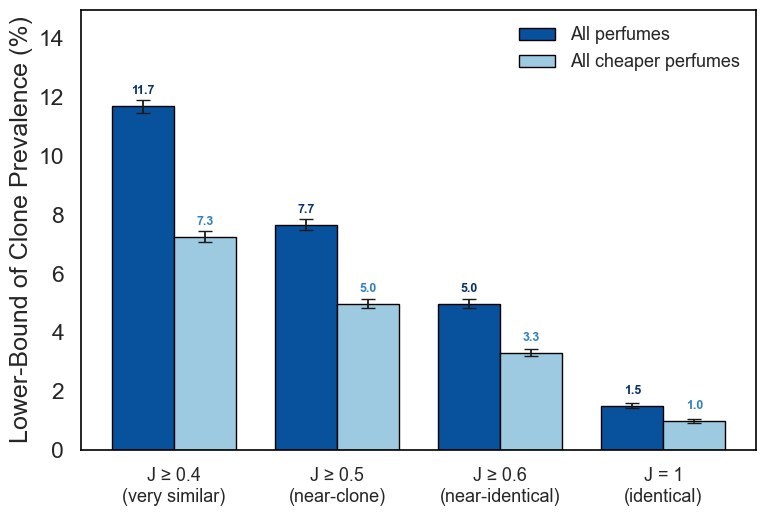

In [9]:
from collections import defaultdict
from utils.utils import parse_notes_weighted
import seaborn as sns

nsets = globals().get('nsets')
if not isinstance(nsets, list):
    nsets = [set(parse_notes_weighted(s)) for s in df['notes']]
yr = df['year'].values; val = df['value'].values
if 'brand' not in df.columns:
    df['brand'] = pd.read_csv("../dataset/Fragrantica.csv", usecols=['brand'])['brand'].values
hn = [str(h).strip().lower() if isinstance(h, str) else None for h in df['brand'].values]
N = len(df)

refs = defaultdict(list)
for r, p in edges:
    refs[int(p)].append(int(r))
cloneJ = np.full(N, np.nan); cheaper = np.zeros(N, bool)
for p, rs in refs.items():
    a = nsets[p]
    if not a:
        continue
    bj, br = -1.0, -1
    for r in rs:
        if hn[p] is None or hn[r] is None or hn[p] == hn[r]:
            continue
        b = nsets[r]
        if not b:
            continue
        j = len(a & b) / len(a | b)
        if j > bj:
            bj, br = j, r
    if br >= 0:
        cloneJ[p] = bj
        if not np.isnan(val[p]) and not np.isnan(val[br]):
            cheaper[p] = val[p] > val[br]

have_notes = np.array([len(s) > 0 for s in nsets])
eligible = have_notes & ~np.isnan(yr)
Nelig = int(eligible.sum())

def boot_ci(rate, n, B=2000, seed=0):
    rng = np.random.default_rng(seed); bs = rng.binomial(n, rate / 100, B) / n * 100
    return float(np.percentile(bs, 2.5)), float(np.percentile(bs, 97.5))

THR = [(0.4, 'J ≥ 0.4\n(very similar)'), (0.5, 'J ≥ 0.5\n(near-clone)'),
       (0.6, 'J ≥ 0.6\n(near-identical)'), (1.0, 'J = 1\n(identical)')]
SERIES = [('any',     'All perfumes',         '#08519c', '#08306b'),
          ('cheaper', 'All cheaper perfumes', '#9ecae1', '#3182bd')]
def _flag(key, thr):
    t = thr - 1e-9
    return (cloneJ >= t) if key == 'any' else (cloneJ >= t) & cheaper

res = []
for thr, _ in THR:
    row = {'thr': thr}
    for key, *_ in SERIES:
        flag = _flag(key, thr) & eligible
        rate = 100 * flag.sum() / Nelig
        row[key] = (rate, boot_ci(rate, Nelig), int(flag.sum()))
    res.append(row)

print(f"Denominator: {Nelig:,} perfumes with notes + release year.  CLONE = reminds of an OLDER, DIFFERENT-house perfume.\n")
_SHORT = {'any': 'All perfumes', 'cheaper': 'All cheaper perfumes'}
print(f"{'criterion':24s}" + "".join(f"{('J>='+format(t,'.2g') if t < 1 else 'J=1'):>15s}" for t, _ in THR))
for key, *_ in SERIES:
    print(f"{_SHORT[key]:24s}" + "".join(f"{res[i][key][0]:6.1f}% ({res[i][key][2]:>5,})".rjust(15) for i in range(len(THR))))
print("\nCROWD-CONFIRMED LOWER BOUNDS (a clone counts only if users annotated the reminds-of link); true rate is higher.")
print("Note overlap alone is NOT enough: shuffling note-sets gives the same ~60% '>=0.5-overlap older neighbour' rate (chance).")

sns.set_theme(style="white", context="talk")
fig, ax = plt.subplots(figsize=(8, 5.5))
x = np.arange(len(res)); w = 0.38
for (key, lbl, col, tcol), off in zip(SERIES, [-w/2, +w/2]):
    vals = [r[key][0] for r in res]
    elo  = [r[key][0] - r[key][1][0] for r in res]
    ehi  = [r[key][1][1] - r[key][0] for r in res]
    ax.bar(x + off, vals, w, yerr=[elo, ehi], color=col, edgecolor='black', linewidth=1.0,
           capsize=5, error_kw=dict(lw=1.3), label=lbl)
    for xi, v in zip(x + off, vals):
        ax.text(xi, v + 0.3, f"{v:.1f}", ha='center', va='bottom', fontsize=9, fontweight='bold', color=tcol)
ax.set_xticks(x); ax.set_xticklabels([lbl for _, lbl in THR], fontsize=13)
ax.set_ylabel('Lower-Bound of Clone Prevalence (%)', fontsize=18)
ax.set_ylim(0, max(r['any'][0] for r in res) * 1.28)
ax.legend(frameon=False, fontsize=13, loc='upper right',
          title='', title_fontsize=11)
for _sp in ax.spines.values():
    _sp.set_visible(True); _sp.set_color('black'); _sp.set_linewidth(1.2)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'Figure_S10.pdf'), format='pdf', dpi=300, bbox_inches='tight')
plt.show()